Logs
- [2026/09/19]   
  Need to understand how to get the correct data, location, and time range.

Download the `.mseed` data

https://service.earthscope.org/fdsnws/dataselect/1/query?net=II&sta=CGJI&loc=00&cha=BHZ&start=2026-09-19T00:00:00.000&end=2026-09-19T00:01:00.000

In [35]:
import obspy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from obspy import UTCDateTime
from obspy.clients.fdsn import Client

In [13]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16,
  'grid.alpha': 0.25})

In [45]:
# 3. Define your specific interval times
# You can use absolute UTC times or relative times
# start_time = UTCDateTime("2026-09-18T01:00:00")  # Update to match your data
# end_time = UTCDateTime("2026-09-18T01:00:10")
start_time = UTCDateTime("2026-08-19T00:00:00")  # Update to match your data
end_time = UTCDateTime("2026-08-19T00:00:10")


In [46]:
client = Client("EARTHSCOPE")
# Fetch the metadata inventory from EarthScope
inv = client.get_stations(
    network="II", 
    station="KAPI", 
    starttime=start_time, 
    endtime=end_time, 
    level="response"
)

# Save/Download the metadata as an XML file
inv.write("my_metadata.xml", format="STATIONXML")
print("StationXML metadata download complete!")

StationXML metadata download complete!


In [47]:
inventory = obspy.read_inventory("my_metadata.xml")
inventory

Inventory created at 2026-09-18T22:59:39.824100Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.57
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (1):
			II
		Stations (1):
			II.KAPI (Kappang, Sulawesi, Indonesia)
		Channels (49):
			II.KAPI.00.BHZ, II.KAPI.00.BH1, II.KAPI.00.BH2, II.KAPI.00.ENZ, 
			II.KAPI.00.EN1, II.KAPI.00.EN2, II.KAPI.00.LCE, II.KAPI.00.LCQ, 
			II.KAPI.00.LDI, II.KAPI.00.LHZ, II.KAPI.00.LH1, II.KAPI.00.LH2, 
			II.KAPI.00.LNZ, II.KAPI.00.LN1, II.KAPI.00.LN2, II.KAPI.00.VCO, 
			II.KAPI.00.VEA, II.KAPI.00.VEC, II.KAPI.00.VEP, II.KAPI.00.VHZ, 
			II.KAPI.00.VH1, II.KAPI.00.VH2, II.KAPI.00.VKI, II.KAPI.00.VMU, 
			II.KAPI.00.VMV, II.KAPI.00.VMW, II.KAPI.01.AE2, II.KAPI.01.AEC, 
			II.KAPI.02.AEC, II.KAPI.02.AEV, II.KAPI.10.BHZ, II.KAPI.10.BH1, 
			II.KAPI.10.BH2, II.KAPI.10.LCE, II.KAPI.10.LCQ, II.KAPI.10.LHZ, 
			II.KAPI.10.LH1, II.KAPI.10.LH2, II.

1 Trace(s) in Stream:
II.KAPI.00.BHZ | 2026-08-19T00:00:00.019538Z - 2026-08-19T00:01:59.994538Z | 40.0 Hz, 4800 samples


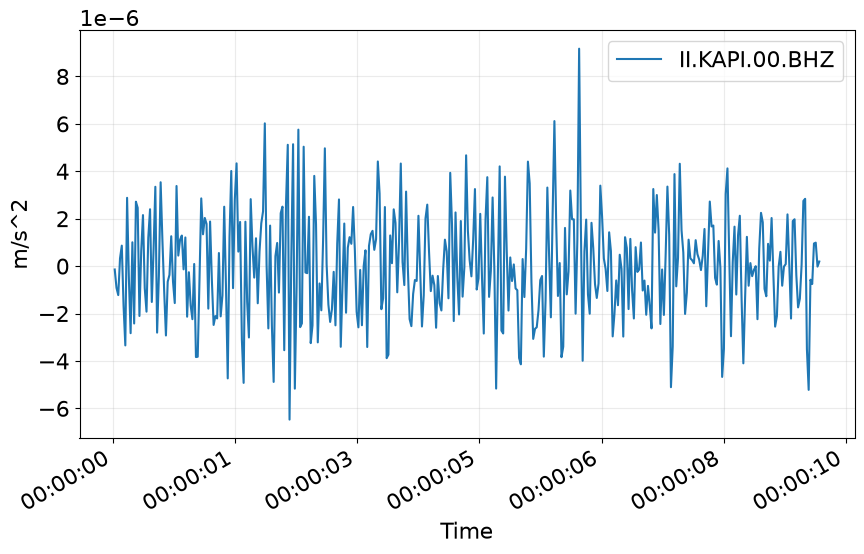

In [48]:
# 1. Read the miniSEED file into an ObsPy Stream
# stream = obspy.read("./fdsnws-dataselect_2026-09-18t16_33_41z.mseed")
# stream = obspy.read("./fdsnws-dataselect_2026-09-18t16_45_38z.mseed")
stream = obspy.read("./fdsnws-dataselect_2026-09-18t22_54_20z.mseed")


print(stream)

# 4. Slice the stream
st_slice = stream.slice(starttime=start_time, endtime=end_time)

st_slice.remove_response(inventory=inventory, output="ACC")

# 5. Plot the selected interval

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(st_slice[0].times("matplotlib"), st_slice[0].data, label=st_slice[0].id)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
fig.autofmt_xdate()
ax.set_xlabel("Time")
ax.set_ylabel("m/s^2")
ax.legend()
ax.grid(True)

plt.show(fig)